## 🛠 Exercises

1. Build and fit a model using the same data we have here but with the MobileNetV2 architecture feature extraction ([`mobilenet_v2_100_224/feature_vector`](https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4)) from TensorFlow Hub, how does it perform compared to our other models?
2. Name 3 different image classification models on TensorFlow Hub that we haven't used.
3. Build a model to classify images of two different things you've taken photos of.
  * You can use any feature extraction layer from TensorFlow Hub you like for this.
  * You should aim to have at least 10 images of each class, for example to build a fridge versus oven classifier, you'll want 10 images of fridges and 10 images of ovens.
4. What is the current best performing model on ImageNet?
  * Hint: you might want to check [sotabench.com](https://www.sotabench.com) for this.

## Import the right modules for tensorflow.keras

In [3]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
print(tf.__version__) # find the version number (should be 2.x+)
print(tf.config.list_physical_devices('GPU'))

version_fn = getattr(tf.keras, "version", None)
if version_fn and version_fn().startswith("3."):
    import tf_keras as keras
else:
    keras = tf.keras

2.19.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## [3-4] Use my own dataset to train a CNN

### 1. Import and inspect data

In [23]:
import os

# Set images directory:
dir_images = "AAO_images/"

# Walk through the images directory and list number of files:
for dirpath, dirnames, filenames in os.walk(dir_images):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'AAO_images/'.
There are 4 directories and 0 images in 'AAO_images/test'.
There are 0 directories and 88 images in 'AAO_images/test/r4a7_PmenorIgual30'.
There are 0 directories and 65 images in 'AAO_images/test/r12a15_Pmayor40'.
There are 0 directories and 39 images in 'AAO_images/test/r4a7_Pmayor30'.
There are 0 directories and 65 images in 'AAO_images/test/r12a15_PmenorIgual40'.
There are 4 directories and 0 images in 'AAO_images/train'.
There are 0 directories and 354 images in 'AAO_images/train/r4a7_PmenorIgual30'.
There are 0 directories and 256 images in 'AAO_images/train/r12a15_Pmayor40'.
There are 0 directories and 159 images in 'AAO_images/train/r4a7_Pmayor30'.
There are 0 directories and 254 images in 'AAO_images/train/r12a15_PmenorIgual40'.


In [25]:
# Get the class names (programmatically, this is much more helpful with a longer list of classes)
import pathlib
import numpy as np

data_dir = pathlib.Path(dir_images+'train/') # turn our training path into a Python path
class_names = np.array(sorted([item.name for item in data_dir.glob('*')])) # created a list of class_names from the subdirectories
print(class_names)

['r12a15_Pmayor40' 'r12a15_PmenorIgual40' 'r4a7_Pmayor30'
 'r4a7_PmenorIgual30']


In [26]:
# View an image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  # Setup target directory (we'll view images from here)
  target_folder = target_dir+target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img,cmap='gray')
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}") # show the shape of the image

  return img

Image shape: (256, 256)


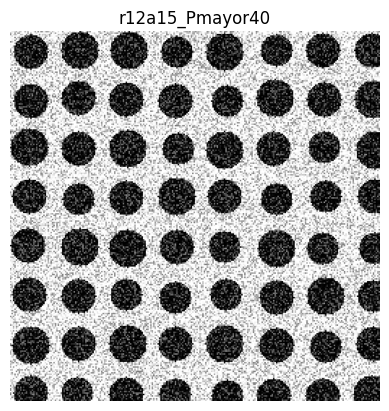

In [27]:
# View a random image from the training dataset
img = view_random_image(target_dir=dir_images+'train/',
                        target_class="r12a15_Pmayor40")

### 2. Preprocess the data

In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 1 and 0, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup the train and test directories
train_dir = dir_images+"train/"
test_dir = dir_images+"test/"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32, # number of images to process at a time 
                                               target_size=(256, 256), # convert all images to be 224 x 224
                                               class_mode="categorical", # type of problem we're working on
                                               color_mode='grayscale',
                                               seed=42)

test_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(256, 256),
                                               class_mode="categorical",
                                               color_mode='grayscale',
                                               seed=42)

Found 1023 images belonging to 4 classes.
Found 257 images belonging to 4 classes.


### 3. Create, fit and evaluate a model (baseline)

In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

# Create our model
model_1 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(256, 256, 1)),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(len(class_names), activation='softmax') # changed to have 10 neurons (same as number of classes) and 'softmax' activation
])

# Compile the model
model_1.compile(loss="categorical_crossentropy", # changed to categorical_crossentropy
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])
model_1.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 254, 254, 10)   │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 252, 252, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 126, 126, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 124, 124, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 122, 122, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 61, 61, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 37210)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │       148,844 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,674 (592.48 KB)

 Trainable params: 151,674 (592.48 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        validation_data=test_data)

Epoch 1/5


I0000 00:00:1745518169.860391   37223 service.cc:148] XLA service 0x7b0e9c005650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745518169.860410   37223 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-04-24 15:09:29.884847: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745518169.979519   37223 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-04-24 15:09:30.005633: W external/local_xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.5.82. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


 8/32 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3323 - loss: 1.3125

I0000 00:00:1745518174.345654   37223 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 200ms/step - accuracy: 0.5390 - loss: 1.0770 - val_accuracy: 0.8444 - val_loss: 0.3762
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9063 - loss: 0.2266 - val_accuracy: 0.8872 - val_loss: 0.1883
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9730 - loss: 0.1017 - val_accuracy: 0.9650 - val_loss: 0.0966
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9929 - loss: 0.0410 - val_accuracy: 0.9650 - val_loss: 0.0932
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9843 - loss: 0.0508 - val_accuracy: 0.9416 - val_loss: 0.1319


In [55]:
# Evaluate on the test data
loss, acc = model_1.evaluate(test_data)
print(f'Accuracy on test dataset: {acc*100:.2f}%')

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9531 - loss: 0.1223
Accuracy on test dataset: 94.16%


In [59]:
# Plot the validation and training data separately
def plot_acc_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """ 
  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

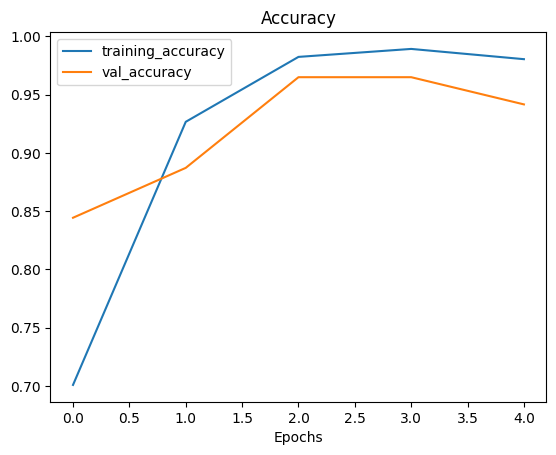

In [60]:
# Check out the model's loss curves on the 10 classes of data (note: this function comes from above in the notebook)
plot_acc_curves(history_1)

### 4. Build a new model with augmented data

In [178]:
# Create ImageDataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0, # rotate the image slightly between 0 and 20 degrees (note: this is an int not a float)
                                             shear_range=0, # shear the image
                                             zoom_range=0.01, # zoom into the image
                                             width_shift_range=0, # shift the image width ways
                                             height_shift_range=0, # shift the image height ways
                                             horizontal_flip=True, # flip the image on the horizontal axis
                                             vertical_flip=True # flip the image on the vertical axis
                                             ) 

# Create ImageDataGenerator training instance without data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.) 

# Create ImageDataGenerator test instance without data augmentation
test_datagen = ImageDataGenerator(rescale=1/255.)

In [179]:
# Import data and augment it from training directory
print("Augmented training images (demo):")
train_data_augmented_demo = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(256, 256),
                                                                   class_mode="categorical", 
                                                                   color_mode='grayscale',
                                                                   batch_size=32,
                                                                   shuffle=False)

# Create non-augmented data batches
print("Non-augmented training images (demo):")
train_data_demo = train_datagen.flow_from_directory(train_dir,
                                               target_size=(256, 256),
                                               class_mode="categorical", 
                                               color_mode='grayscale',
                                               batch_size=32,
                                               shuffle=False)

print("Augmented training images (real):")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(256, 256),
                                                                   class_mode="categorical", 
                                                                   color_mode='grayscale',
                                                                   batch_size=32,
                                                                   shuffle=True)

# Create non-augmented data batches
print("Non-augmented training images (real):")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(256, 256),
                                               class_mode="categorical", 
                                               color_mode='grayscale',
                                               batch_size=32,
                                               shuffle=True)

print("Unchanged test images:")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(256, 256),
                                             class_mode="categorical", 
                                             color_mode='grayscale',
                                             batch_size=32,
                                             shuffle=True)

Augmented training images (demo):
Found 1023 images belonging to 4 classes.
Non-augmented training images (demo):
Found 1023 images belonging to 4 classes.
Augmented training images (real):
Found 1023 images belonging to 4 classes.
Non-augmented training images (real):
Found 1023 images belonging to 4 classes.
Unchanged test images:
Found 257 images belonging to 4 classes.


In [180]:
# Get data batch samples
images, labels = next(train_data_demo)
augmented_images, augmented_labels = next(train_data_augmented_demo) # Note: labels aren't augmented, they stay the same

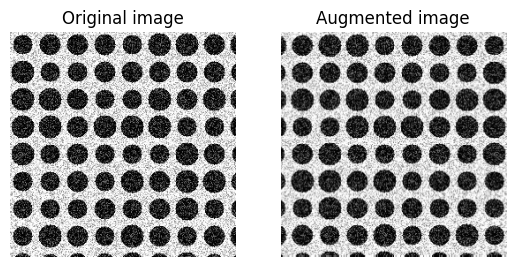

In [186]:
# Show original image and augmented image
random_number = random.randint(0, 31) # we're making batches of size 32, so we'll get a random instance
fig, ax = plt.subplots(1,2)
ax[0].imshow(images[random_number],cmap='gray')
ax[0].set_title(f"Original image")
ax[0].axis(False)
ax[1].imshow(augmented_images[random_number],cmap='gray')
ax[1].set_title(f"Augmented image")
ax[1].axis(False);

In [187]:
# Clone the model (use the same architecture)
model_2 = tf.keras.models.clone_model(model_1)

# Compile the cloned model (same setup as used for model_10)
model_2.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

# Fit the model
history_2 = model_2.fit(train_data_augmented, # use augmented data
                        epochs=10,
                        validation_data=test_data)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.4476 - loss: 1.2197 - val_accuracy: 0.6070 - val_loss: 1.0025
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8859 - loss: 0.3595 - val_accuracy: 0.7471 - val_loss: 0.6312
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9134 - loss: 0.2196 - val_accuracy: 0.8988 - val_loss: 0.2799
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9342 - loss: 0.1643 - val_accuracy: 0.8911 - val_loss: 0.2823
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9230 - loss: 0.1880 - val_accuracy: 0.9650 - val_loss: 0.1165
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9734 - loss: 0.0894 - val_accuracy: 0.8521 - val_loss: 0.3929
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9686 - loss: 0.0814 - val_accuracy: 0.9222 - val_loss: 0.1749
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9760 - loss: 0.0623 - val_accuracy: 0.8560 - v

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9376 - loss: 0.1608
Accuracy on test dataset: 93.77%


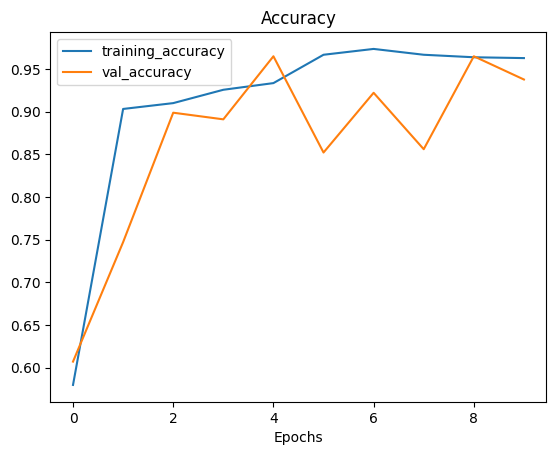

In [188]:
# Evaluate on the test data
loss, acc = model_2.evaluate(test_data)
print(f'Accuracy on test dataset: {acc*100:.2f}%')
plot_acc_curves(history_2)

In [271]:
# Create our model
model_3 = Sequential([
  Conv2D(10, 5, activation='relu', input_shape=(256, 256, 1)),
  MaxPool2D(),
  Conv2D(10, 4, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(len(class_names), activation='softmax') # changed to have 10 neurons (same as number of classes) and 'softmax' activation
])

# Compile the cloned model (same setup as used for model_10)
model_3.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

model_3.summary()

# Fit the model
history_3 = model_3.fit(train_data_augmented, # use augmented data
                        epochs=5,
                        validation_data=test_data)

/home/meneses/miniconda3/envs/py12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 252, 252, 10)   │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 126, 126, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 123, 123, 10)   │         1,610 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 61, 61, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 59, 59, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 29, 29, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 8410)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │        33,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,424 (142.28 KB)

 Trainable params: 36,424 (142.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.3654 - loss: 1.3334 - val_accuracy: 0.6965 - val_loss: 0.7361
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.7560 - loss: 0.5844 - val_accuracy: 0.6809 - val_loss: 0.7339
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8755 - loss: 0.3357 - val_accuracy: 0.8210 - val_loss: 0.4051
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9258 - loss: 0.1923 - val_accuracy: 0.8132 - val_loss: 0.4604
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9489 - loss: 0.1397 - val_accuracy: 0.8016 - val_loss: 0.4953


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7932 - loss: 0.5076
Accuracy on test dataset: 80.16%


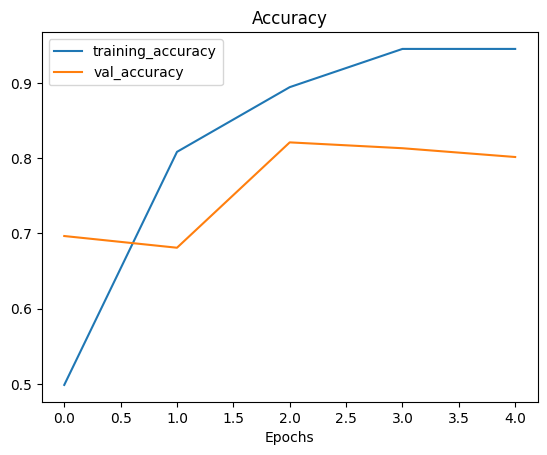

In [272]:
# Evaluate on the test data
loss, acc = model_3.evaluate(test_data)
print(f'Accuracy on test dataset: {acc*100:.2f}%')
plot_acc_curves(history_3)

### Making predictions with our trained model

In [221]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=256):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=1)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [240]:
def pred_and_plot(model, filename, label, class_names):
    """
    Imports an image located at filename, makes a prediction on it with
    a trained model and plots the image with the predicted class as the title.
    """
    # Import the target image and preprocess it
    img = load_and_prep_image(filename)
    
    # Make a prediction
    pred = model.predict(tf.expand_dims(img, axis=0))

    # Get the predicted class
    if len(pred[0]) > 1: # check for multi-class
        pred_class = class_names[pred.argmax()] # if more than one output, take the max
    else:
        pred_class = class_names[int(tf.round(pred)[0][0])] # if only one output, round
    pred_color = 'green' if pred_class == label else 'red'
    confidence = 100*tf.reduce_max(pred) # [%]
    
    # Plot the image and predicted class
    plt.imshow(img,cmap='gray')
    if pred_class == label:
        title = f"Pred: {pred_class}, {confidence:.0f}% | Correct!"
    else:
        title = f"Pred: {pred_class}, {confidence:.0f}% | True: {label}"
    plt.title(title,color=pred_color)
    plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


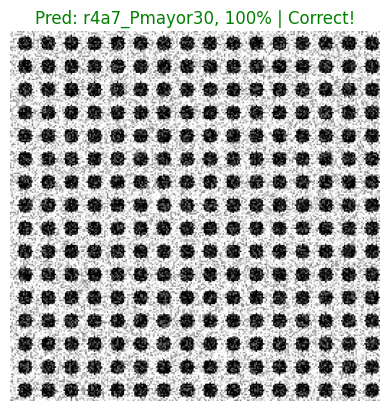

In [265]:
# Choose image file from test dataset:
class_folder = os.listdir(test_dir)[np.random.randint(len(class_names))]+'/'
file = os.listdir(test_dir+class_folder)[np.random.randint(len(os.listdir(test_dir+class_folder)))]
file_dir = test_dir+class_folder+file

# Predict and plot:
pred_and_plot(model_2,file_dir,class_folder[:-1],class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


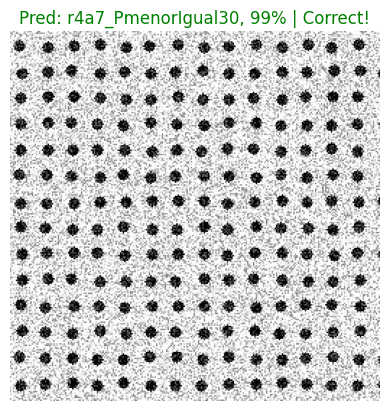

In [270]:
# Choose image file from test dataset:
class_folder = os.listdir(test_dir)[np.random.randint(len(class_names))]+'/'
file = os.listdir(test_dir+class_folder)[np.random.randint(len(os.listdir(test_dir+class_folder)))]
file_dir = test_dir+class_folder+file

# Predict and plot:
pred_and_plot(model_1,file_dir,class_folder[:-1],class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


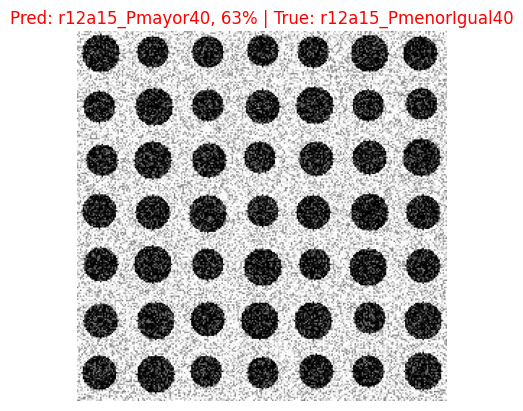

In [287]:
# Choose image file from test dataset:
class_folder = os.listdir(test_dir)[np.random.randint(len(class_names))]+'/'
file = os.listdir(test_dir+class_folder)[np.random.randint(len(os.listdir(test_dir+class_folder)))]
file_dir = test_dir+class_folder+file

# Predict and plot:
pred_and_plot(model_3,file_dir,class_folder[:-1],class_names)

## 📖 Extra-curriculum

* Read through the [TensorFlow Transfer Learning Guide](https://www.tensorflow.org/tutorials/images/transfer_learning) and define the main two types of transfer learning in your own words.
* Go through the [Transfer Learning with TensorFlow Hub tutorial](https://www.tensorflow.org/tutorials/images/transfer_learning_with_hub) on the TensorFlow website and rewrite all of the code yourself into a new Google Colab notebook making comments about what each step does along the way.
* We haven't covered fine-tuning with TensorFlow Hub in this notebook, but if you'd like to know more, go through the [fine-tuning a TensorFlow Hub model tutorial](https://www.tensorflow.org/hub/tf2_saved_model#fine-tuning) on the TensorFlow homepage.How to fine-tune a tensorflow hub model:  
* Look into [experiment tracking with Weights & Biases](https://www.wandb.com/experiment-tracking), how could you integrate it with our existing TensorBoard logs?